Para hacer representaciones de textos e imágenes para luego aplicar agrupación (clustering) en Python, usaremos:

1. **Textos**:
   - Representación con **Bolsa de Palabras (Bag of Words - BoW)**.
   - Representación con **Embeddings** usando `Word2Vec` o `Doc2Vec`.

2. **Imágenes**:
   - Representación con **Vectores de píxeles**.

Luego aplicaremos métodos de agrupación como:
- **K-Means**.
- **Clustering Jerárquico**.
- **Kernel PCA**.
- **Técnicas de reducción de dimensionalidad** como `t-SNE`.

---



## **1. Representación de Textos**
### **A. Bolsa de Palabras (BoW)**
Usamos `CountVectorizer` o `TfidfVectorizer` de `sklearn.feature_extraction.text`.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec, Doc2Vec
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import KernelPCA
from PIL import Image
import os
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
import nltk
import re
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import pandas as pd


# --- 1. Representación de Textos ---
texts = [
    # Textos sobre Mascotas
    "El gato persigue al ratón en el jardín mientras el perro lo observa desde la terraza.",
    "Un perro ladra fuertemente en la calle cada vez que un desconocido se acerca a la casa.",
    "Los pájaros cantan por la mañana cuando sale el sol y llenan el aire con su melodiosa sinfonía.",
    "El gato duerme plácidamente sobre el sofá después de haber jugado con su pelota de lana.",
    "Un ratón corre rápidamente por la cocina mientras el gato intenta atraparlo sin éxito.",
    "Los peces nadan tranquilamente en la pecera, ajenos al ruido del hogar.",
    "El loro repite palabras sin cesar, sorprendiendo a todos los que lo escuchan hablar.",
    "El hámster da vueltas en su rueda sin parar, disfrutando de su ejercicio nocturno.",
    "El conejo mordisquea una zanahoria mientras observa a los niños jugar en el patio.",
    "La tortuga se mueve lentamente por el jardín, buscando un lugar soleado para descansar.",

    # Textos sobre Deportes
    "El fútbol es el deporte más popular del mundo, con millones de aficionados en todos los continentes.",
    "El equipo de baloncesto entrenó intensamente para el campeonato que se jugará la próxima semana.",
    "En la natación, la técnica de respiración es fundamental para mejorar el rendimiento en competencias.",
    "El corredor de maratón se preparó durante meses para completar los 42 kilómetros de la carrera.",
    "En el tenis, la precisión y la velocidad son esenciales para vencer a un oponente fuerte.",
    "El ciclista recorrió más de 100 kilómetros en un solo día, desafiando el calor y la fatiga.",
    "El levantamiento de pesas requiere mucha disciplina y una técnica adecuada para evitar lesiones.",
    "El esquí en la montaña es un deporte extremo que combina adrenalina y control del equilibrio.",
    "El automovilismo es un deporte que exige reflejos rápidos y una gran capacidad de concentración.",
    "En el boxeo, los golpes bien calculados y la estrategia mental son clave para ganar una pelea.",

    # Textos sobre Ciencia de Datos
    "El aprendizaje automático ha revolucionado la industria, permitiendo la creación de modelos predictivos precisos.",
    "El análisis de datos es fundamental para la toma de decisiones empresariales en grandes compañías tecnológicas.",
    "Los algoritmos de inteligencia artificial pueden clasificar imágenes con una precisión superior al 95%.",
    "En el procesamiento de lenguaje natural, los modelos transformadores han mejorado la comprensión de textos complejos.",
    "Los científicos de datos utilizan Python y R para realizar análisis estadísticos avanzados.",
    "El clustering de datos permite segmentar clientes según sus preferencias y comportamientos de compra.",
    "Los modelos de redes neuronales profundas son capaces de generar texto y crear imágenes realistas.",
    "El Big Data ha cambiado la manera en que las empresas manejan grandes volúmenes de información.",
    "Las métricas de evaluación como la precisión y el recall son esenciales para medir la calidad de un modelo.",
    "El preprocesamiento de datos incluye técnicas como la normalización, eliminación de valores atípicos y transformación de variables."
]


# --- A. Bolsa de Palabras (BoW) ---
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(texts).toarray()

# Obtener los nombres de las columnas (las palabras en la bolsa de palabras)
column_names = vectorizer.get_feature_names_out()
column_names
len(column_names)
X_bow


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

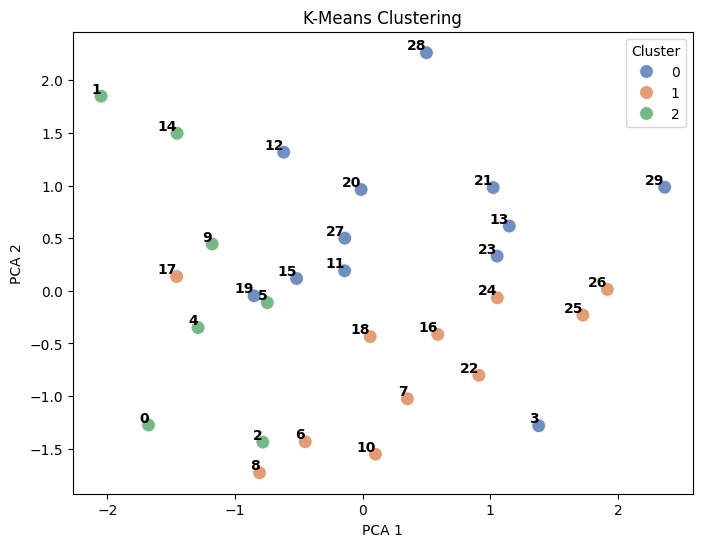

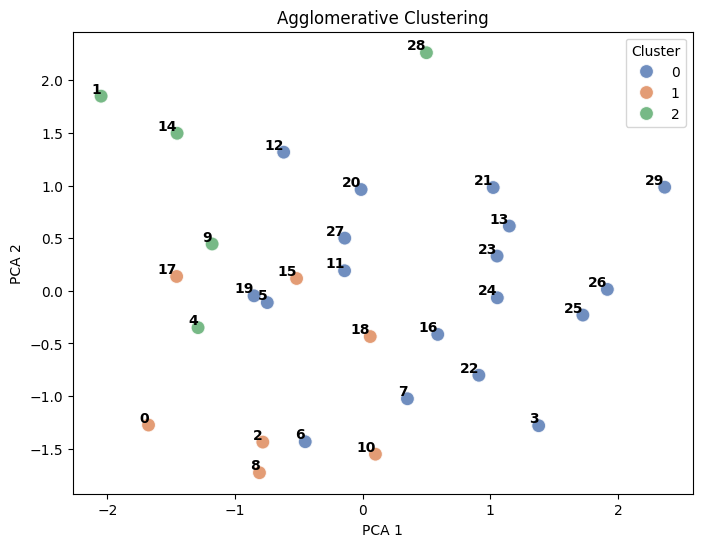

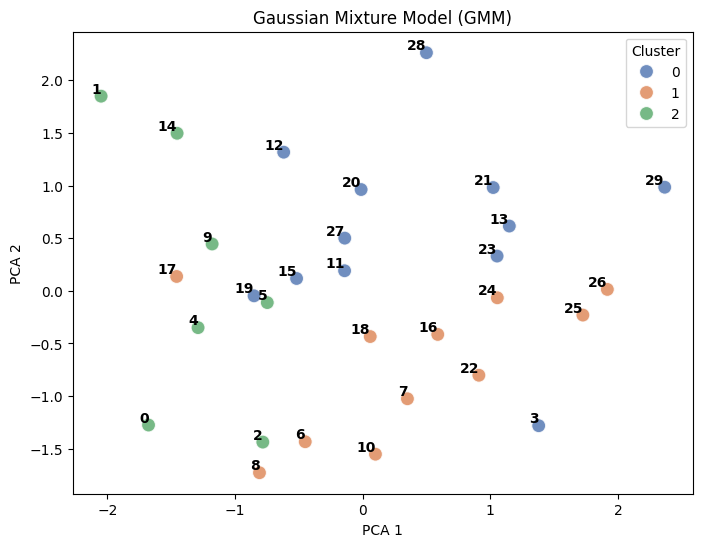

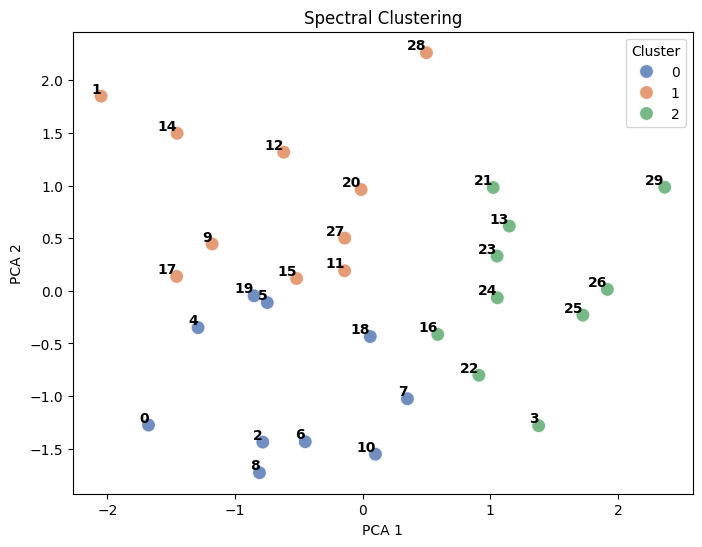


🔹 Resultados del Clustering:

                                                Texto  KMeans  Agglomerative  \
0   El gato persigue al ratón en el jardín mientra...       2              1   
1   Un perro ladra fuertemente en la calle cada ve...       2              2   
2   Los pájaros cantan por la mañana cuando sale e...       2              1   
3   El gato duerme plácidamente sobre el sofá desp...       0              0   
4   Un ratón corre rápidamente por la cocina mient...       2              2   
5   Los peces nadan tranquilamente en la pecera, a...       2              0   
6   El loro repite palabras sin cesar, sorprendien...       1              0   
7   El hámster da vueltas en su rueda sin parar, d...       1              0   
8   El conejo mordisquea una zanahoria mientras ob...       1              1   
9   La tortuga se mueve lentamente por el jardín, ...       2              2   
10  El fútbol es el deporte más popular del mundo,...       1              1   
11  El eq

In [4]:
# --- 3. Aplicar PCA para Reducción a 2D ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_bow)

# --- 4. Aplicar Clustering ---
n_clusters = 3  # Definir número de clusters esperado

# K-Means Clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X_bow)
labels_kmeans = kmeans.labels_


# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=n_clusters).fit(X_bow)
labels_agglo = agglo.labels_

# Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=n_clusters, random_state=42).fit(X_bow)
labels_gmm = gmm.predict(X_bow)

# Spectral Clustering
spectral = SpectralClustering(n_clusters=n_clusters, random_state=42, affinity='nearest_neighbors').fit(X_bow)
labels_spectral = spectral.labels_

# --- 5. Visualizar Resultados con PCA ---
def plot_clusters(X_pca, labels, title):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="deep", s=100, alpha=0.8)

    # Etiquetar cada punto con su índice de texto
    for i, (x, y) in enumerate(zip(X_pca[:, 0], X_pca[:, 1])):
        plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', fontweight='bold')

    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend(title="Cluster")
    plt.show()

# Graficar todos los métodos
plot_clusters(X_pca, labels_kmeans, "K-Means Clustering")
plot_clusters(X_pca, labels_agglo, "Agglomerative Clustering")
plot_clusters(X_pca, labels_gmm, "Gaussian Mixture Model (GMM)")
plot_clusters(X_pca, labels_spectral, "Spectral Clustering")

# --- 6. Mostrar Resultados en DataFrame ---
df_results = pd.DataFrame({
    "Texto": texts,
    "KMeans": labels_kmeans,
    "Agglomerative": labels_agglo,
    "GMM": labels_gmm,
    "Spectral": labels_spectral
})

print("\n🔹 Resultados del Clustering:\n")
print(df_results)


In [5]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
import nltk
import string

# Descargar stopwords si no están disponibles
nltk.download('stopwords')
nltk.download('punkt')

# Definir stopwords en español
stop_words = set(stopwords.words('spanish'))

# Crear el Stemmer para español
stemmer = SnowballStemmer("spanish")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [16]:


# --- 1. Representación de Textos ---
texts = [
    # Textos sobre Mascotas
    "El gato persigue otra cosa",
    "Un gato ladra fuertemente en la calle cada vez que un desconocido se acerca acerca acerca a la casa.",
    "Los gato cantan por la mañana cuando sale el sol y llenan el aire con su melodiosa sinfonía.",
    "El gato duerme plácidamente sobre el sofá después de haber jugado con su pelota de lana.",
    "Un gato corre rápidamente por la cocina mientras el gato intenta atraparlo sin éxito.",
    "Los gatos nadan tranquilamente en la pecera, ajenos al ruido del hogar.",
    "El gato repite palabras sin cesar, sorprendiendo a todos los que lo escuchan hablar.",
    "El gato da vueltas en su rueda sin parar, disfrutando de su ejercicio nocturno.",
    "El gato mordisquea una zanahoria mientras observa a los niños jugar en el patio.",
    "La gato se mueve lentamente por el jardín, buscando un lugar soleado para descansar.",

    # Textos sobre Deportes
    "El fútbol es el deporte más popular del mundo, con millones de aficionados en todos los continentes.",
    "El equipo de baloncesto entrenó intensamente para el campeonato que se jugará la próxima semana.",
    "En la natación, la técnica de respiración es fundamental para mejorar el rendimiento en competencias.",
    "El futbol de maratón se preparó durante meses para completar los 42 kilómetros de la carrera.",
    "En el tenis, la precisión y la velocidad son esenciales para vencer a un oponente fuerte.",
    "El ciclista recorrió más de 100 kilómetros en un solo día, desafiando el calor y la fatiga.",
    "El levantamiento de pesas requiere mucha disciplina y una técnica adecuada para evitar lesiones.",
    "El esquí en la montaña es un deporte extremo que combina adrenalina y control del equilibrio.",
    "El automovilismo es un deporte que exige reflejos rápidos y una gran capacidad de concentración.",
    "En el boxeo, los golpes bien calculados y la estrategia mental son clave para ganar una pelea.",

    # Textos sobre Ciencia de Datos
    "El aprendizaje automático de datos ha revolucionado la industria, permitiendo la creación de modelos predictivos precisos.",
    "El análisis de datos es fundamental para la toma de decisiones empresariales en grandes compañías tecnológicas.",
    "Los algoritmos de datos de inteligencia artificial pueden clasificar imágenes con una precisión superior al 95%.",
    "En el procesamientode datos de lenguaje natural, los modelos transformadores han mejorado la comprensión de textos complejos.",
    "Los científicos de datos utilizan Python y R para realizar análisis estadísticos avanzados.",
    "El clustering de datos permite segmentar clientes según sus preferencias y comportamientos de compra.",
    "Los modelos de redes neuronales profundas son capaces de generar texto y datos crear imágenes realistas.",
    "El Big Data ha cambiado la manera en que las empresas manejan grandes volúmenes dedatos información.",
    "Las métricas de datos de evaluación como la precisión y el recall son esenciales para medir la calidad de un modelo.",
    "El preprocesamiento de datos incluye técnicas como la normalización, eliminación de valores atípicos y transformación de variables."
]



# Función de preprocesamiento del texto
def preprocess_text(text):
    # 1. Convertir a minúsculas
    text = text.lower()

    # 2. Reemplazar números por símbolos
    text = re.sub(r'\b\d+\b', 'd', text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)

    # 3. Tokenizar el texto
    words = text.split(" ")

    # 4. Eliminar stopwords y aplicar stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    # 5. Reunir las palabras nuevamente en un solo string
    return ' '.join(words)

# Aplicar la función de preprocesamiento a cada texto
processed_texts = [preprocess_text(text) for text in texts]

# Mostrar textos preprocesados
print("🔹 Textos después del preprocesamiento:")
for i, text in enumerate(processed_texts):
    print(f"{i+1}. {text}")

# --- Aplicar Bolsa de Palabras (BoW) ---
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(processed_texts).toarray()

# Obtener nombres de las columnas (palabras)
column_names = vectorizer.get_feature_names_out()
print("\n🔹 Nombres de las Columnas (Palabras):")
print(len(column_names))
# Convertir a DataFrame para visualizar mejor
df_bow = pd.DataFrame(X_bow, columns=column_names)

print("\n🔹 Matriz de Bolsa de Palabras (BoW):")
print(df_bow)


🔹 Textos después del preprocesamiento:
1. gat persig cos
2. gat ladr fuertement call cad vez desconoc acerc acerc acerc cas
3. gat cant mañan sal sol llen air melodi sinfon
4. gat duerm placid sof despues hab jug pelot lan
5. gat corr rapid cocin mientr gat intent atrap exit
6. gat nad tranquil pecer ajen ruid hog
7. gat repit palabr ces sorprend escuch habl
8. gat da vuelt rued par disfrut ejercici nocturn
9. gat mordisque zanahori mientr observ niñ jug pati
10. gat muev lent jardin busc lug sol descans
11. futbol deport popul mund millon aficion continent
12. equip baloncest entren intens campeonat jug proxim seman
13. natacion tecnic respir fundamental mejor rendimient competent
14. futbol maraton prepar mes complet d kilometr carrer
15. tenis precision veloc esencial venc oponent fuert
16. ciclist recorr d kilometr sol dia desafi calor fatig
17. levant pes requier much disciplin tecnic adecu evit lesion
18. esqu montañ deport extrem combin adrenalin control equilibri
19. automovil 

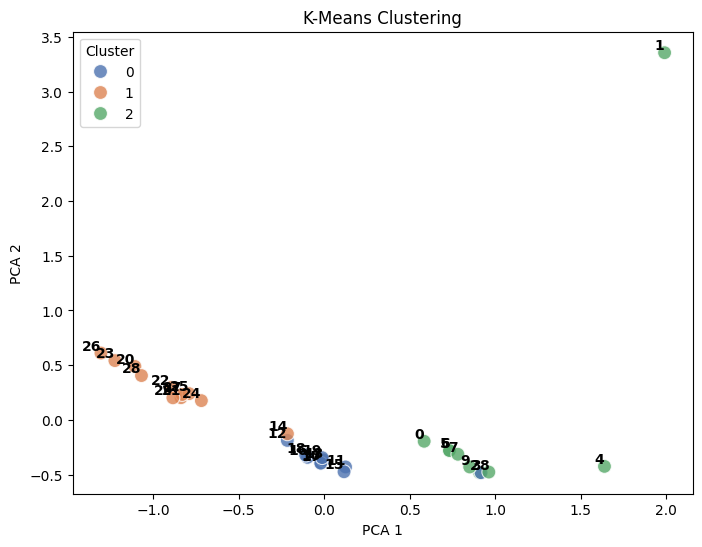

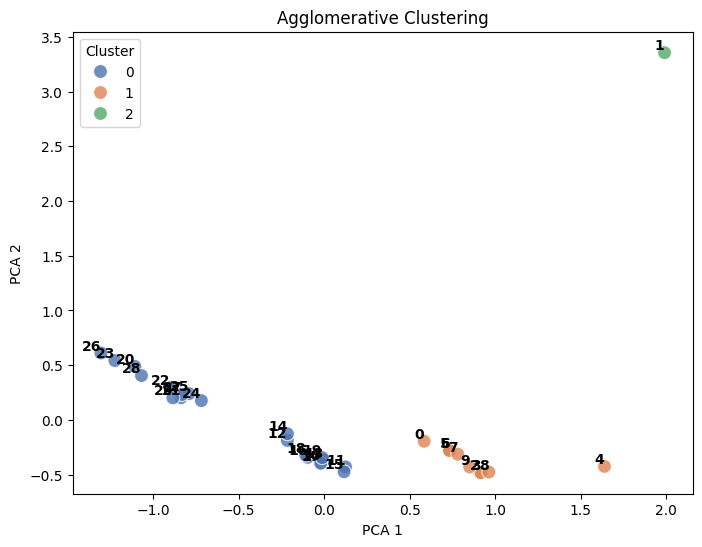

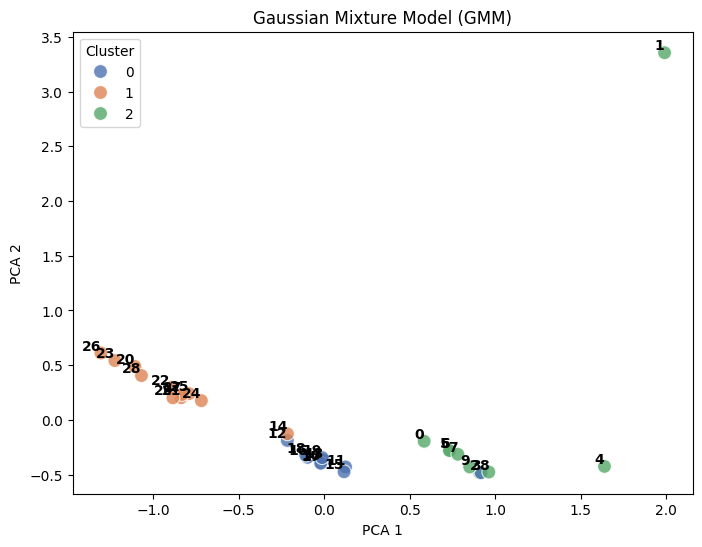

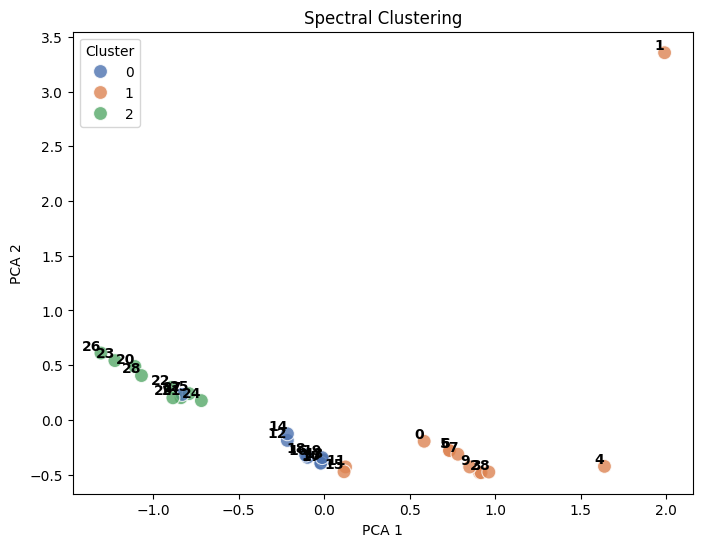


🔹 Resultados del Clustering:

                                                Texto  KMeans  Agglomerative  \
0                          El gato persigue otra cosa       2              1   
1   Un gato ladra fuertemente en la calle cada vez...       2              2   
2   Los gato cantan por la mañana cuando sale el s...       2              1   
3   El gato duerme plácidamente sobre el sofá desp...       0              1   
4   Un gato corre rápidamente por la cocina mientr...       2              1   
5   Los gatos nadan tranquilamente en la pecera, a...       2              1   
6   El gato repite palabras sin cesar, sorprendien...       2              1   
7   El gato da vueltas en su rueda sin parar, disf...       2              1   
8   El gato mordisquea una zanahoria mientras obse...       2              1   
9   La gato se mueve lentamente por el jardín, bus...       2              1   
10  El fútbol es el deporte más popular del mundo,...       0              0   
11  El eq

In [17]:
# --- 3. Aplicar PCA para Reducción a 2D ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_bow)

# --- 4. Aplicar Clustering ---
n_clusters = 3  # Definir número de clusters esperado

# K-Means Clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X_bow)
labels_kmeans = kmeans.labels_


# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=n_clusters).fit(X_bow)
labels_agglo = agglo.labels_

# Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=n_clusters, random_state=42).fit(X_bow)
labels_gmm = gmm.predict(X_bow)

# Spectral Clustering
spectral = SpectralClustering(n_clusters=n_clusters, random_state=42, affinity='nearest_neighbors').fit(X_bow)
labels_spectral = spectral.labels_

# --- 5. Visualizar Resultados con PCA ---
def plot_clusters(X_pca, labels, title):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="deep", s=100, alpha=0.8)

    # Etiquetar cada punto con su índice de texto
    for i, (x, y) in enumerate(zip(X_pca[:, 0], X_pca[:, 1])):
        plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', fontweight='bold')

    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend(title="Cluster")
    plt.show()

# Graficar todos los métodos
plot_clusters(X_pca, labels_kmeans, "K-Means Clustering")
plot_clusters(X_pca, labels_agglo, "Agglomerative Clustering")
plot_clusters(X_pca, labels_gmm, "Gaussian Mixture Model (GMM)")
plot_clusters(X_pca, labels_spectral, "Spectral Clustering")

# --- 6. Mostrar Resultados en DataFrame ---
df_results = pd.DataFrame({
    "Texto": texts,
    "KMeans": labels_kmeans,
    "Agglomerative": labels_agglo,
    "GMM": labels_gmm,
    "Spectral": labels_spectral
})

print("\n🔹 Resultados del Clustering:\n")
print(df_results)

---
# 📌 EMBEDDINGS


## 🔹 SECCIÓN 1: Introducción a los Embeddings 🔹


📌 **Embeddings: Representación Numérica del Lenguaje**
Los **embeddings** son representaciones vectoriales densas de palabras o documentos en un espacio de **dimensiones reducidas**, donde las palabras con significados similares están más cerca entre sí.

## ✅ **¿Por qué son importantes los embeddings?**
- **Capturan relaciones semánticas y sintácticas** entre palabras.
- **Permiten realizar operaciones matemáticas con palabras.**
- **Mejoran la comprensión del lenguaje natural (NLP).**

## 🔥 **Tipos de Embeddings**
1️⃣ **Word Embeddings** → Representan palabras individuales (**Word2Vec, GloVe**).  
2️⃣ **Document Embeddings** → Representan frases o documentos completos (**Doc2Vec**).  
3️⃣ **Contextual Embeddings** → Consideran el **contexto de una palabra** en una oración (**BERT, GPT**).  



## 🔹 SECCIÓN 2: Word2Vec y sus Modelos 🔹



# 📌 **Word2Vec: Modelos de Embeddings**
Word2Vec es un modelo de aprendizaje profundo que **aprende representaciones vectoriales de palabras** a partir de corpus de texto.

 ✅ **Modelos principales de Word2Vec**
🔹 **1. CBOW (Continuous Bag of Words)**  
   - Predice una palabra dada su **contexto**.  
   - Más eficiente en corpus pequeños.  
   - Tiende a capturar mejor la **sintaxis** de las palabras.  

🔹 **2. Skip-gram**  
   - Predice el contexto dado una **palabra central**.  
   - Funciona mejor en corpus grandes.  
   - Captura mejor la **semántica** de las palabras.  

✅ **Ejemplo**:
- Frase: `"El gato está en el tejado"`
- **CBOW** → `["El", "está", "en", "el"] → "gato"`
- **Skip-gram** → `"gato" → ["El", "está", "en", "tejado"]`


## 🔹 SECCIÓN 3: Cargar Word2Vec en Español 🔹

📌 **Cargar Word2Vec en Español**
Usaremos el modelo **"glove-twitter-es"** de Gensim, que contiene embeddings entrenados en tweets en español.



In [3]:
# --- 📌 Importar Librerías ---
import numpy as np
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns



In [4]:

print(list(api.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [5]:
# --- 📌 Descargar el Modelo Word2Vec Preentrenado en Español ---
print("Descargando embeddings preentrenados...")
model = api.load("glove-wiki-gigaword-200")  # Modelo en español de 100 dimensiones



Descargando embeddings preentrenados...
[==================================================] 100.0% 252.1/252.1MB downloaded


In [6]:
# --- 📌 Verificar Dimensiones del Modelo ---
print(f"\nDimensiones del embedding: {model.vector_size}")  # Debe ser 200
print(f"Número total de palabras en el vocabulario: {len(model.key_to_index)}")




Dimensiones del embedding: 200
Número total de palabras en el vocabulario: 400000



## 🔹 SECCIÓN 4: Aritmética de Palabras 🔹



📌 **Aritmética de Palabras**
Uno de los resultados más sorprendentes de Word2Vec es que permite realizar **operaciones matemáticas con palabras**.

 🔥 **Ejemplo Famoso**

$\text{"rey"} - \text{"hombre"} + \text{"mujer"} = \text{"reina"}$


In [7]:


# --- 📌 Función para Realizar Aritmética de Palabras ---
def aritmetica_palabras(palabra1, palabra2, palabra3):
    try:
        resultado = model.most_similar(positive=[palabra1, palabra3], negative=[palabra2], topn=1)
        print(f"\n{palabra1} - {palabra2} + {palabra3} = {resultado[0][0]} (Similitud: {resultado[0][1]:.4f})")
    except KeyError as e:
        print(f"Error: {e}")

# --- 📌 Ejemplos de Aritmética de Palabras ---
aritmetica_palabras("king", "man", "woman")  # Debería ser "reina"
aritmetica_palabras("madrid", "spain", "france")  # Debería ser "París pero..."
aritmetica_palabras("gentleman", "man", "woman")  # Debería ser "lady pero..."




king - man + woman = queen (Similitud: 0.6979)

madrid - spain + france = paris (Similitud: 0.7957)

gentleman - man + woman = ladies (Similitud: 0.5190)


In [13]:
aritmetica_palabras("ran", "run", "swim")



ran - run + swim = swam (Similitud: 0.6492)


In [22]:
model.most_similar('man', topn=5)

('those', 0.44150108098983765)

---
## 🔹 SECCIÓN 5: Clustering y PCA 🔹

 📌 **Clustering y Visualización con PCA**
Para entender mejor cómo se organizan las palabras en el espacio de embeddings, aplicaremos:
✅ **PCA** → Reduce la dimensionalidad de 50D a 2D para visualizar los datos.  
✅ **KMeans** → Agrupa palabras en clusters semánticos.


In [36]:


# --- 📌 Seleccionar Palabras ---
palabras_interesantes = ["king", "queen", "man", "woman", "madrid", "spain", "france",
                          "doctor", "nurse", "teacher", "student", "apple", "banana",
                          "fruit", "car", "bus", "train", "paris", "mexico", "guatemala", "usa", "seul", "argentina", "tokyo", "korea", "japan"]


# Obtener vectores
vectores = np.array([model[word] for word in palabras_interesantes])



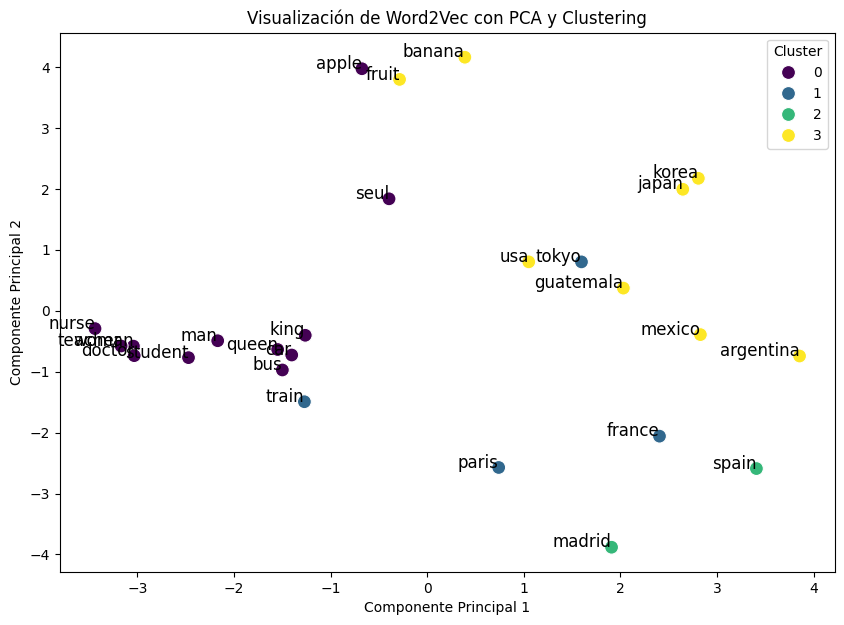

In [37]:
# --- 📌 Aplicar PCA ---
pca = PCA(n_components=2)
vectores_2d = pca.fit_transform(vectores)

# --- 📌 Aplicar KMeans ---
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(vectores)

# --- 📌 Visualización ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x=vectores_2d[:, 0], y=vectores_2d[:, 1], hue=labels, palette="viridis", s=100)

# Añadir etiquetas
for i, word in enumerate(palabras_interesantes):
    plt.text(vectores_2d[i, 0], vectores_2d[i, 1], word, fontsize=12, ha='right')

plt.title("Visualización de Word2Vec con PCA y Clustering")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()


In [38]:
# --- 📌 Importar librerías necesarias ---
import numpy as np
from gensim.models import KeyedVectors

# --- 📌 Cargar el modelo Word2Vec (Reemplaza con tu modelo) ---
# Si ya tienes un modelo cargado, usa ese. Aquí se asume que 'model' está definido.
# model = KeyedVectors.load_word2vec_format("ruta/al/modelo.vec", binary=False)  # Ejemplo de carga

# --- 📌 Función para obtener el vector promedio y la palabra más cercana ---
def palabra_mas_cercana(lista_palabras, modelo):

    # Obtener los vectores de las palabras en la lista
    vectores = [modelo[word] for word in lista_palabras if word in modelo]

    if not vectores:
        return "Ninguna palabra está en el vocabulario del modelo."

    # Calcular el vector promedio
    vector_promedio = np.mean(vectores, axis=0)

    # Encontrar la palabra más similar al vector promedio
    palabra_similar = modelo.similar_by_vector(vector_promedio, topn=1)[0][0]

    return palabra_similar

# --- 📌 Lista de palabras de ejemplo ---
palabras = ["train", "car", "plane", "ship", "bus", "helicopter"]

# --- 📌 Ejecutar la función ---
palabra_cercana = palabra_mas_cercana(palabras, model)

# --- 📌 Mostrar resultado ---
print(f"\nLa palabra más cercana al vector promedio de {palabras} es: '{palabra_cercana}'")



La palabra más cercana al vector promedio de ['train', 'car', 'plane', 'ship', 'bus', 'helicopter'] es: 'bus'


### Doc2vec

In [39]:
# =====================================================
# 🔹 SECCIÓN 1: Introducción a los Embeddings 🔹
# =====================================================

"""
## ✅ **¿Por qué son importantes los embeddings de documentos?**
- **Capturan relaciones semánticas y contextuales** entre documentos.
- **Permiten realizar clustering y clasificación de textos.**
- **Mejoran la comprensión del lenguaje natural (NLP).**

## 🔥 **Modelos de Embeddings para Documentos**
1️⃣ **Word Embeddings** → Representan palabras individuales (**Word2Vec, GloVe**).
2️⃣ **Document Embeddings** → Representan frases o documentos completos (**Doc2Vec**).
3️⃣ **Contextual Embeddings** → Consideran el **contexto de cada palabra** (**BERT, GPT**).
"""

# =====================================================
# 🔹 SECCIÓN 2: Doc2Vec y su Funcionamiento 🔹
# =====================================================

"""
# 📌 **Doc2Vec: Embeddings para Documentos**
Doc2Vec es una extensión de Word2Vec diseñada para representar textos completos en un vector.

## ✅ **Modelos principales de Doc2Vec**
🔹 **1. PV-DM (Distributed Memory Model of Paragraph Vectors)**
   - Similar a CBOW en Word2Vec.
   - Usa el **contexto de las palabras** para predecir una palabra central.

🔹 **2. PV-DBOW (Distributed Bag of Words)**
   - Similar a Skip-gram en Word2Vec.
   - Predice las palabras dentro de un documento usando solo su ID.

✅ **Ejemplo**:
- Frase: `"El gato está en el tejado"`
- **PV-DM** → `"El", "gato", "está", "en" → [Vector de Documento]`
- **PV-DBOW** → `[Vector de Documento] → "tejado"`
"""

# =====================================================
# 🔹 SECCIÓN 3: Generar Embeddings con Doc2Vec 🔹
# =====================================================

# --- 📌 Instalar y importar librerías ---
!pip install gensim matplotlib seaborn scikit-learn



In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# --- 📌 Definir un conjunto de documentos de ejemplo ---
documentos = [
    "Machine learning is transforming the industry",
    "Artificial intelligence is the future of technology",
    "Deep learning improves the accuracy of AI models",
    "Neural networks are powerful tools for data analysis",
    "Data science and statistics are key in business",
    "Python and R are popular languages for data science",
    "Football is the most watched sport worldwide",
    "Basketball and soccer are popular team sports",
    "Tennis requires agility and precision",
    "Athletes train hard to improve their performance",
    "Cooking is both an art and a science",
    "Baking requires precise measurements and timing",
    "Gourmet chefs create unique culinary experiences",
    "Fast food is convenient but often unhealthy",
    "Traveling allows people to explore new cultures",
    "Tourism is a major industry in many countries",
    "Airports facilitate global travel and connections",
    "Historical landmarks attract many tourists",
]



In [44]:
# --- 📌 Preparar documentos para entrenamiento ---
tagged_docs = [TaggedDocument(doc.split(), [i]) for i, doc in enumerate(documentos)]
print(tagged_docs)
# --- 📌 Entrenar un modelo Doc2Vec ---
model = Doc2Vec(tagged_docs, vector_size=20, window=2, min_count=1, workers=4, epochs=50)

# --- 📌 Obtener los embeddings de los documentos ---
doc_vectors = np.array([model.dv[i] for i in range(len(documentos))])

#doc_vectors



[TaggedDocument(words=['Machine', 'learning', 'is', 'transforming', 'the', 'industry'], tags=[0]), TaggedDocument(words=['Artificial', 'intelligence', 'is', 'the', 'future', 'of', 'technology'], tags=[1]), TaggedDocument(words=['Deep', 'learning', 'improves', 'the', 'accuracy', 'of', 'AI', 'models'], tags=[2]), TaggedDocument(words=['Neural', 'networks', 'are', 'powerful', 'tools', 'for', 'data', 'analysis'], tags=[3]), TaggedDocument(words=['Data', 'science', 'and', 'statistics', 'are', 'key', 'in', 'business'], tags=[4]), TaggedDocument(words=['Python', 'and', 'R', 'are', 'popular', 'languages', 'for', 'data', 'science'], tags=[5]), TaggedDocument(words=['Football', 'is', 'the', 'most', 'watched', 'sport', 'worldwide'], tags=[6]), TaggedDocument(words=['Basketball', 'and', 'soccer', 'are', 'popular', 'team', 'sports'], tags=[7]), TaggedDocument(words=['Tennis', 'requires', 'agility', 'and', 'precision'], tags=[8]), TaggedDocument(words=['Athletes', 'train', 'hard', 'to', 'improve', '

array([[-2.78459452e-02, -2.64838859e-02, -4.57875580e-02,
         4.86992411e-02,  1.61470342e-02,  1.99746364e-03,
        -5.20020239e-02, -2.00347360e-02, -5.05691692e-02,
         6.18777471e-03,  8.74419603e-03,  2.42583118e-02,
        -2.29892712e-02, -1.86788496e-02, -1.38887363e-02,
        -3.80291268e-02,  1.33300470e-02,  4.70142104e-02,
        -5.04986979e-02, -1.95916034e-02],
       [-1.92500390e-02,  1.82818547e-02, -2.36163810e-02,
         1.85707714e-02,  2.74562817e-02, -4.00165170e-02,
        -4.57032956e-02, -4.35086153e-02,  2.31257565e-02,
        -5.02375849e-02,  2.21241508e-02,  3.53328846e-02,
        -3.47411297e-02, -2.70034876e-02, -4.25041141e-03,
         1.58516355e-02, -6.09787414e-03, -4.34549861e-02,
        -2.10904945e-02,  4.99374513e-03],
       [-1.22389225e-02, -2.93370206e-02,  2.96948198e-02,
        -3.56781594e-02,  1.09362137e-02, -2.25462150e-02,
        -4.08933520e-05,  6.95085211e-04,  2.60332469e-02,
        -4.78012450e-02, -2.0

In [45]:
# =====================================================
# 🔹 SECCIÓN 4: Clustering con KMeans 🔹
# =====================================================

"""
# 📌 **Clustering de Documentos con KMeans**
Para identificar grupos de documentos similares, aplicaremos **KMeans**, que organiza los textos en **clusters basados en sus embeddings**.

## ✅ **¿Por qué usar KMeans?**
- Permite **agrupar automáticamente documentos con temas similares**.
- Reduce la complejidad de grandes volúmenes de texto.
- Puede ayudar a segmentar contenido en análisis de texto.
"""

# --- 📌 Aplicar KMeans para agrupar los documentos ---
num_clusters = 3  # Definir número de clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(doc_vectors)



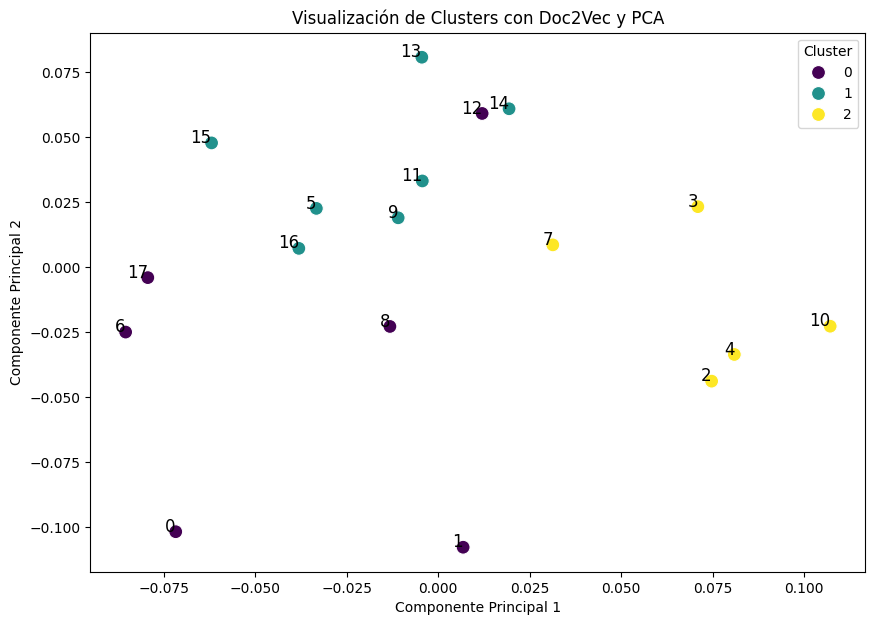

In [46]:
# =====================================================
# 🔹 SECCIÓN 5: Reducción de Dimensiones con PCA 🔹
# =====================================================

"""
# 📌 **Reducción de Dimensiones con PCA**
Para visualizar los embeddings en **2D**, aplicamos **PCA** (Análisis de Componentes Principales).

## ✅ **¿Por qué usar PCA?**
- Reduce la dimensionalidad de los embeddings de **50D a 2D**.
- Facilita la visualización y comprensión de los clusters generados.
"""

# --- 📌 Aplicar PCA para reducir a 2 dimensiones ---
pca = PCA(n_components=2)
doc_vectors_2d = pca.fit_transform(doc_vectors)

# =====================================================
# 🔹 SECCIÓN 6: Visualización de Clusters 🔹
# =====================================================

"""
# 📌 **Visualización de Clusters en 2D**
Mostramos los documentos en un gráfico donde:
- **Cada punto representa un documento**.
- **Los colores indican los diferentes clusters** encontrados por KMeans.
"""

# --- 📌 Crear gráfico con seaborn ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x=doc_vectors_2d[:, 0], y=doc_vectors_2d[:, 1], hue=labels, palette="viridis", s=100)

# --- 📌 Añadir etiquetas con los textos originales ---
for i, txt in enumerate(documentos):
    plt.text(doc_vectors_2d[i, 0], doc_vectors_2d[i, 1], str(i), fontsize=12, ha='right')

plt.title("Visualización de Clusters con Doc2Vec y PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()


## Embeddings con transformers

In [47]:
# --- 📌 Instalar librerías necesarias ---
!pip install transformers torch



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 842.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 63.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [48]:
# --- 📌 Importar librerías ---
import torch
from transformers import BertTokenizer, BertModel

# --- 📌 Cargar el Tokenizer y el Modelo BERT ---
model_name = "bert-base-uncased"  # Modelo BERT en inglés
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

# --- 📌 Función para obtener embeddings de BERT ---
def obtener_embeddings_bert(texto):
    """
    Toma un texto de entrada y devuelve su embedding generado por BERT.

    Parámetros:
    - texto (str): Texto de entrada.

    Retorna:
    - Embedding de la oración (vector promedio de los tokens).
    """
    # Tokenizar el texto y convertirlo en tensores
    tokens = tokenizer(texto, return_tensors="pt", padding=True, truncation=True, max_length=512)

    # Pasar los tokens por el modelo BERT
    with torch.no_grad():
        outputs = model(**tokens)

    # Extraer los embeddings de la última capa oculta
    embeddings = outputs.last_hidden_state  # (batch_size, num_tokens, hidden_dim)

    # Obtener el embedding promedio de la oración (ignorar [CLS] y [SEP])
    embedding_promedio = embeddings.mean(dim=1).squeeze().numpy()

    return embedding_promedio

# --- 📌 Ejemplo de uso ---
texto_ejemplo = "Artificial intelligence is transforming the world."
embedding = obtener_embeddings_bert(texto_ejemplo)

# --- 📌 Mostrar resultados ---
print(f"\nEmbedding de la oración '{texto_ejemplo}':\n")
print(embedding)
print(f"\nDimensiones del embedding: {embedding.shape}")  # 768 dimensiones


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


Embedding de la oración 'Artificial intelligence is transforming the world.':

[ 2.11774513e-01 -5.31601720e-02 -9.44616944e-02 -2.96494998e-02
  2.47977465e-01 -4.06640381e-01  2.68269479e-01  8.77298594e-01
 -9.61257331e-03 -7.77769864e-01  5.92202902e-01 -2.11687833e-01
 -6.28706932e-01  4.12319422e-01 -3.96013260e-01 -3.27514894e-02
  1.62790120e-01  2.69061267e-01 -2.19334707e-01  5.80513716e-01
 -3.04318786e-01 -5.11539057e-02 -3.61510403e-02  8.92686725e-01
  2.00278267e-01 -3.41670722e-01 -5.21488547e-01  3.65171731e-02
 -2.83319652e-01 -5.79118133e-02  3.82947773e-02 -1.26707191e-02
 -4.41856444e-01 -2.95547694e-01  9.21558309e-03 -1.51642174e-01
 -1.09741479e-01 -1.64093792e-01 -5.20430624e-01  3.21601212e-01
 -8.60160351e-01 -5.41673750e-02 -2.04850674e-01  2.70142376e-01
 -3.30567926e-01 -2.15077430e-01 -1.35216583e-02  2.00586617e-01
  1.73303410e-01 -2.86574095e-01 -5.15926600e-01 -7.12245628e-02
 -8.59996602e-02  7.03156367e-02 -5.19155003e-02  4.58924890e-01
  1.703032

In [49]:
# --- 📌 Instalar librerías necesarias ---
#!pip install transformers torch scikit-learn matplotlib seaborn

# --- 📌 Importar librerías ---
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertModel
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# =====================================================
# 🔹 SECCIÓN 1: Cargar Modelo BERT 🔹
# =====================================================
"""
# 📌 **Cargar Modelo BERT**
Este código usa **BERT (bert-base-uncased)** para convertir textos en **vectores de 768 dimensiones**.
"""

# --- 📌 Cargar el Tokenizer y el Modelo BERT ---
model_name = "bert-base-uncased"  # Modelo en inglés
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

# =====================================================
# 🔹 SECCIÓN 2: Función para Obtener Embeddings 🔹
# =====================================================
"""
# 📌 **Obtener Embeddings de Documentos**
Esta función recibe una lista de textos y devuelve los **embeddings promedio** de cada documento.
"""

def obtener_embeddings_bert(lista_textos):
    """
    Genera embeddings de BERT para una lista de textos.

    Parámetros:
    - lista_textos (list): Lista de textos.

    Retorna:
    - embeddings (numpy array): Matriz con embeddings de los documentos.
    """
    embeddings = []

    for texto in lista_textos:
        # Tokenizar y convertir en tensores
        tokens = tokenizer(texto, return_tensors="pt", padding=True, truncation=True, max_length=512)

        # Obtener embeddings de la última capa oculta
        with torch.no_grad():
            outputs = model(**tokens)
        embedding_promedio = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        embeddings.append(embedding_promedio)

    return np.array(embeddings)

# =====================================================
# 🔹 SECCIÓN 3: Obtener Embeddings de Documentos 🔹
# =====================================================

"""
# 📌 **Lista de Documentos**
Usaremos 18 textos para generar los embeddings con BERT.
"""

documentos = [
    "Machine learning is transforming the industry",
    "Artificial intelligence is the future of technology",
    "Deep learning improves the accuracy of AI models",
    "Neural networks are powerful tools for data analysis",
    "Data science and statistics are key in business",
    "Python and R are popular languages for data science",
    "Football is the most watched sport worldwide",
    "Basketball and soccer are popular team sports",
    "Tennis requires agility and precision",
    "Athletes train hard to improve their performance",
    "Cooking is both an art and a science",
    "Baking requires precise measurements and timing",
    "Gourmet chefs create unique culinary experiences",
    "Fast food is convenient but often unhealthy",
    "Traveling allows people to explore new cultures",
    "Tourism is a major industry in many countries",
    "Airports facilitate global travel and connections",
    "Historical landmarks attract many tourists",
]

# --- 📌 Obtener los embeddings de los documentos ---
print("\nGenerando embeddings con BERT...")
embeddings = obtener_embeddings_bert(documentos)
print(f"Dimensiones de los embeddings: {embeddings.shape}")  # (18, 768)




Generando embeddings con BERT...
Dimensiones de los embeddings: (18, 768)


In [54]:
# =====================================================
# 🔹 SECCIÓN 4: Clustering con KMeans 🔹
# =====================================================
"""
# 📌 **Agrupación de Documentos con KMeans**
Aplicamos **KMeans** para organizar los textos en **clusters** según sus embeddings.
"""

# --- 📌 Aplicar KMeans ---
num_clusters = 5  # Definir el número de clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)



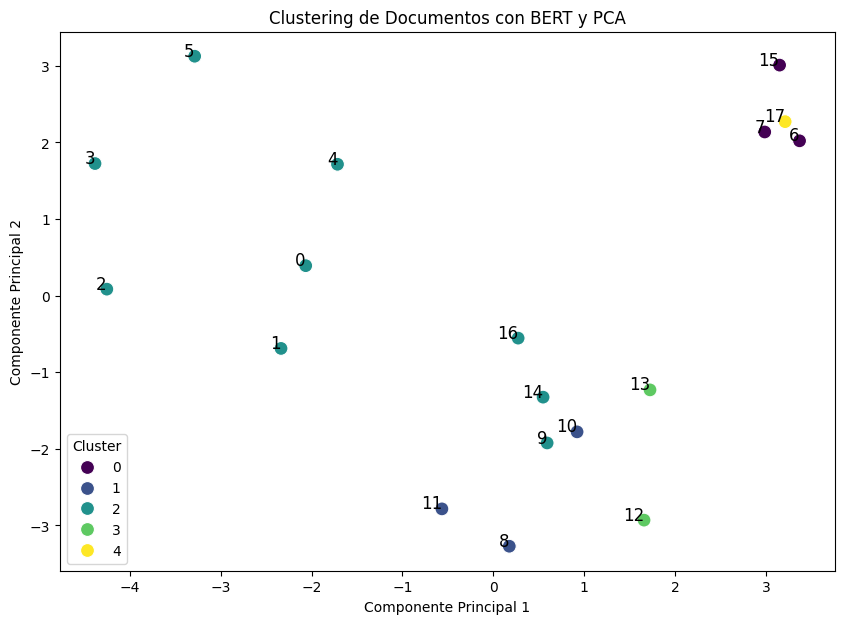

In [55]:
# =====================================================
# 🔹 SECCIÓN 5: Reducción de Dimensiones con PCA 🔹
# =====================================================
"""
# 📌 **Reducción de Dimensiones con PCA**
Reducimos los embeddings de **768D a 2D** para visualizar los clusters.
"""

# --- 📌 Aplicar PCA ---
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# =====================================================
# 🔹 SECCIÓN 6: Visualización de Clusters 🔹
# =====================================================
"""
# 📌 **Visualización de Clusters en 2D**
Mostramos un gráfico donde:
- **Cada punto representa un documento**.
- **Los colores indican los clusters generados por KMeans**.
"""

# --- 📌 Crear gráfico ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=labels, palette="viridis", s=100)

# --- 📌 Agregar etiquetas con los textos originales ---
for i, txt in enumerate(documentos):
    plt.text(embeddings_2d[i, 0], embeddings_2d[i, 1], str(i), fontsize=12, ha='right')

plt.title("Clustering de Documentos con BERT y PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()


In [61]:
documentos[15]

'Tourism is a major industry in many countries'

# Imágenes

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# 📌 **Histogramas y Descriptores en Visión por Computadora**  

Los **histogramas de imágenes** y los **descriptores de características** son herramientas fundamentales en **visión por computadora**. Se utilizan para analizar imágenes, comparar similitudes y agruparlas en categorías mediante técnicas como **clustering**.

---

## 🔹 **1. Histograma de Escala de Grises**  
### 📌 **¿Qué es?**  
Un **histograma de escala de grises** es una representación gráfica de la distribución de los valores de intensidad en una imagen en **blanco y negro**.  

### ✅ **¿Cómo funciona?**  
1. **Cada píxel de la imagen tiene un valor entre 0 (negro) y 255 (blanco).**  
2. Se cuentan **cuántos píxeles tienen cada intensidad** y se agrupan en un gráfico.  
3. **El eje X representa la intensidad (0 a 255).**  
4. **El eje Y representa la cantidad de píxeles con esa intensidad.**  

### 🔥 **Ejemplo Visual de un Histograma de Escala de Grises**
Si una imagen tiene más píxeles oscuros, el histograma tendrá **más valores altos en las intensidades bajas** (cerca de 0).  
Si la imagen es brillante, los valores estarán **más altos en intensidades cercanas a 255**.  

---

## 🔹 **2. Histograma de Color (RGB)**  
### 📌 **¿Qué es?**  
El **histograma de color** es similar al de escala de grises, pero en lugar de una sola escala de valores (0-255), tenemos **tres canales de color: rojo (R), verde (G) y azul (B)**.

### ✅ **¿Cómo funciona?**  
1. **Cada píxel de la imagen tiene 3 valores**: **(R, G, B)**, cada uno en el rango **0-255**.  
2. Se calcula un histograma **para cada canal por separado**.  
3. Se grafica un histograma con **tres curvas** (roja, verde y azul).  

### 🔥 **Ejemplo Visual de un Histograma de Color**  
- Si la imagen tiene **mucho rojo**, el histograma del canal **rojo tendrá valores altos**.  
- Si es una imagen con **colores equilibrados**, los tres histogramas tendrán una distribución más uniforme.  

📌 **El histograma de color es útil para comparar imágenes en términos de composición cromática**.



In [2]:
# --- 📌 Instalar dependencias necesarias ---
!pip install opencv-python matplotlib numpy seaborn scikit-learn



In [77]:
# =====================================================
# 🔹 SECCIÓN 1: Cargar Imágenes y Extraer Histogramas 🔹
# =====================================================
"""
# 📌 **Carga de imágenes y extracción de histogramas**
1️⃣ Se leen imágenes de la carpeta `imagenes/`.
2️⃣ Se extrae el **histograma en escala de grises**.
3️⃣ Se extrae el **histograma de color (RGB)**.
4️⃣ Se concatenan los histogramas en un **vector único**.
"""
# --- 📌 Importar librerías ---
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [5]:
# --- 📌 Función para obtener el histograma en escala de grises ---
def obtener_histograma_gris(imagen):
    """
    Calcula el histograma en escala de grises de una imagen.

    Parámetros:
    - imagen: Imagen en formato OpenCV.

    Retorna:
    - histograma normalizado en un vector 1D.
    """
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)  # Convertir a escala de grises
    hist = cv2.calcHist([gris], [0], None, [256], [0, 256])  # Calcular histograma
    hist = cv2.normalize(hist, hist).flatten()  # Normalizar y convertir a vector 1D
    return hist



In [6]:
# --- 📌 Función para obtener el histograma de color ---
def obtener_histograma_color(imagen):
    """
    Calcula los histogramas de los canales R, G y B de una imagen.

    Parámetros:
    - imagen: Imagen en formato OpenCV.

    Retorna:
    - Vector concatenado de histogramas de los 3 canales.
    """
    hist_color = []
    for i in range(3):  # Canales B, G, R
        hist = cv2.calcHist([imagen], [i], None, [256], [0, 256])  # Histograma
        hist = cv2.normalize(hist, hist).flatten()  # Normalizar y convertir a vector 1D
        hist_color.extend(hist)  # Concatenar al vector final
    return np.array(hist_color)



In [52]:
def get_vector(ruta_carpeta, tipo = "gris"): #tipo = {gris, color, combinado}

  imagenes = [];
  nombres_imagenes = [];
  vectores_histogramas = [];
  for archivo in os.listdir(ruta_carpeta):
      if archivo.endswith(".jpeg") or archivo.endswith(".png"):  # Filtrar imágenes
          ruta = os.path.join(ruta_carpeta, archivo)
          img = cv2.imread(ruta)  # Leer imagen
          if img is not None:
              imagenes.append(img)
              nombres_imagenes.append(archivo)

              # Obtener histogramas
              if tipo == "gris" or tipo == "combinado":
                hist_gris = obtener_histograma_gris(img)
              if tipo == "color" or tipo == "combinado":
                hist_color = obtener_histograma_color(img)



              if tipo == "combinado":
                vector_final = np.concatenate((hist_gris, hist_color))
                vectores_histogramas.append(vector_final)

              elif tipo == "gris":
                vectores_histogramas.append(hist_gris)
              elif tipo == "color":
                vectores_histogramas.append(hist_color)


  return vectores_histogramas, nombres_imagenes;



In [53]:
# --- 📌 Importar librerías necesarias ---
import numpy as np
import matplotlib.pyplot as plt

# --- 📌 Función para calcular y graficar el histograma ---
def graficar_histograma_gris(vector_gris):
    """
    Calcula y grafica el histograma de una imagen en escala de grises.

    Parámetros:
    - vector_gris (numpy array): Vector de píxeles en escala de grises (valores entre 0 y 255).
    """
    # Calcular histograma con rango 0-256 para incluir el valor 255
    intensidades = np.arange(256)

    # Graficar histograma
    plt.figure(figsize=(10, 5))
    plt.bar(intensidades, vector_gris, width=1, color='gray', edgecolor='black', alpha=0.7)
    plt.title("Histograma Normalizado en Escala de Grises")
    plt.xlabel("Intensidad de píxeles (0-255)")
    plt.ylabel("Frecuencia Normalizada")
    plt.xlim([0, 255])
    plt.ylim([0, max(vector_gris) + 0.01])  # Ajustar eje Y para visibilidad
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()


In [66]:
# --- 📌 Función para graficar el histograma de una imagen en color ---
def graficar_histograma_color(histograma_concatenado):
    """
    Grafica el histograma normalizado de una imagen a color (RGB) a partir de un solo vector concatenado.

    Parámetros:
    - histograma_concatenado (numpy array): Histograma normalizado concatenado de los 3 canales (Rojo, Verde, Azul).
      Debe tener una longitud de 256 * 3 = 768.
    """
    if len(histograma_concatenado) != 768:
        raise ValueError("El histograma debe tener exactamente 768 valores (256 por canal RGB).")

    # Separar los histogramas de los 3 canales
    hist_b = histograma_concatenado[:256]  # Primeros 256 valores → Azuk
    hist_g = histograma_concatenado[256:512]  # Siguientes 256 valores → Verde
    hist_r = histograma_concatenado[512:]  # Últimos 256 valores → Rojo

    # Crear eje de intensidades (0 a 255)
    intensidades = np.arange(256)

    # Crear figura
    plt.figure(figsize=(10, 5))

    # Graficar histogramas de los 3 canales
    plt.plot(intensidades, hist_r, color="red", label="Rojo", linewidth=1.5)
    plt.plot(intensidades, hist_g, color="green", label="Verde", linewidth=1.5)
    plt.plot(intensidades, hist_b, color="blue", label="Azul", linewidth=1.5)

    # Configuración de la gráfica
    plt.title("Histograma Normalizado de una Imagen a Color")
    plt.xlabel("Intensidad de píxeles (0-255)")
    plt.ylabel("Frecuencia Normalizada")
    plt.xlim([0, 255])
    plt.ylim([0, max(max(hist_r), max(hist_g), max(hist_b)) + 0.01])  # Ajustar eje Y
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()

In [67]:
# --- 📌 Cargar imágenes desde la carpeta `imagenes/` ---
ruta_carpeta = "drive/MyDrive/Imagenes/"

In [68]:
imagenes = []
nombres_imagenes = []
vectores_histogramas = []
vectores_histogramas, nombres_imagenes = get_vector(ruta_carpeta, tipo = "gris")
print("\n📥 Cargando imágenes...")
print(f"✅ {len(nombres_imagenes)} imágenes cargadas y procesadas.")
print(nombres_imagenes[6])
print(vectores_histogramas[6])
print(len(vectores_histogramas[6]))


📥 Cargando imágenes...
✅ 10 imágenes cargadas y procesadas.
7.jpeg
[0.00916384 0.04113072 0.04113072 0.03953237 0.03452423 0.02834397
 0.02504072 0.02685218 0.0263194  0.0221637  0.02301615 0.02205715
 0.02205715 0.02184403 0.02077847 0.01790145 0.01523755 0.01736867
 0.01427854 0.01513099 0.01577033 0.01555721 0.01491788 0.01726211
 0.0177949  0.01896701 0.01555721 0.01523755 0.01481132 0.01310642
 0.00980318 0.01118841 0.01076218 0.01108185 0.01278675 0.01001629
 0.01044251 0.01065563 0.01097529 0.0092704  0.01086874 0.01214741
 0.00905728 0.01065563 0.01086874 0.00809828 0.01118841 0.01033596
 0.00937695 0.00777861 0.0085245  0.01172119 0.01012284 0.00916384
 0.00873761 0.01086874 0.01118841 0.01225397 0.01033596 0.01001629
 0.00948351 0.00863106 0.00980318 0.00969662 0.01065563 0.00969662
 0.00937695 0.00884417 0.00799172 0.00895073 0.00948351 0.00948351
 0.0102294  0.0092704  0.00969662 0.00873761 0.01033596 0.01001629
 0.0102294  0.0102294  0.01108185 0.00884417 0.00703271 0.009

In [69]:
nombres_imagenes_gris = []
vectores_histogramas_gris = []
nombres_imagenes_color = []
vectores_histogramas_color = []

vectores_histogramas_gris, nombres_imagenes_gris = get_vector(ruta_carpeta, tipo = "gris")
vectores_histogramas_color, nombres_imagenes_color = get_vector(ruta_carpeta, tipo = "color")

5.jpeg


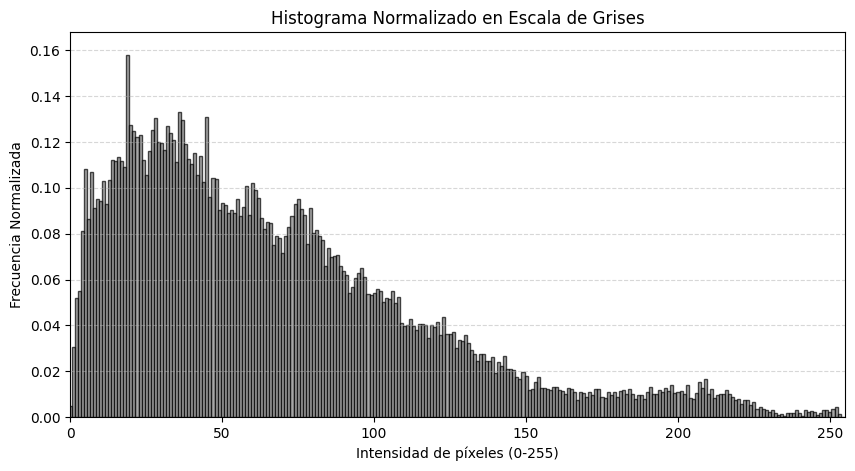

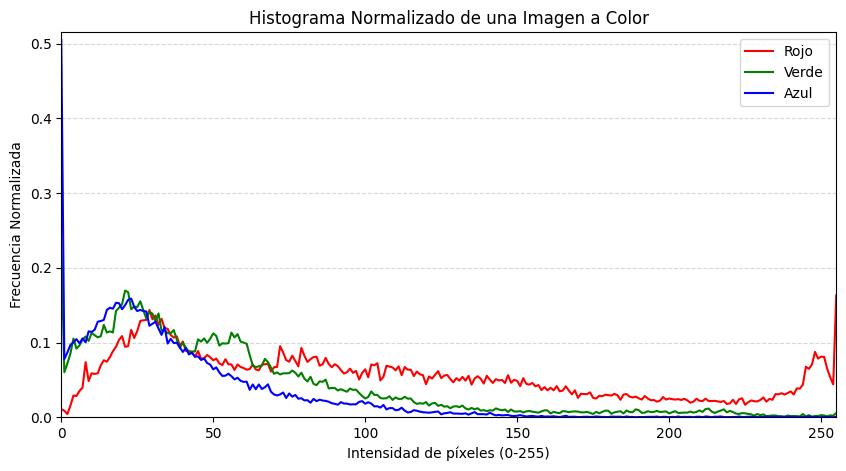

In [71]:
print(nombres_imagenes[4])
graficar_histograma_gris(vectores_histogramas_gris[4])
graficar_histograma_color(vectores_histogramas_color[4])


In [73]:
# =====================================================
# 🔹 SECCIÓN 2: Clustering con KMeans 🔹
# =====================================================
"""
# 📌 **Agrupación de imágenes con KMeans**
Aplicamos **KMeans** para organizar imágenes con histogramas similares en **clusters**.
"""

# --- 📌 Convertir lista de histogramas en matriz ---
vectores_histogramas = np.array(vectores_histogramas)

# --- 📌 Aplicar KMeans ---
num_clusters = 2  # Número de clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(vectores_histogramas)

# =====================================================
# 🔹 SECCIÓN 3: Reducción de Dimensiones con PCA 🔹
# =====================================================
"""
# 📌 **Reducción de Dimensiones con PCA**
Reducimos la dimensionalidad de los histogramas de **768D a 2D** para visualizarlos.
"""



'\n# 📌 **Reducción de Dimensiones con PCA**\nReducimos la dimensionalidad de los histogramas de **768D a 2D** para visualizarlos.\n'

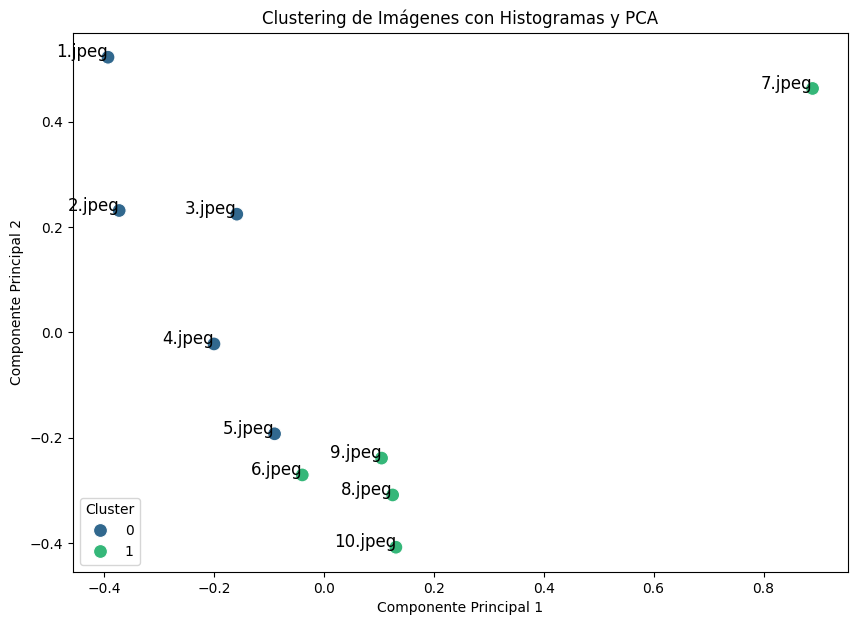

In [74]:
# --- 📌 Aplicar PCA ---
pca = PCA(n_components=2)
vectores_2d = pca.fit_transform(vectores_histogramas)

# =====================================================
# 🔹 SECCIÓN 4: Visualización de Clusters 🔹
# =====================================================
"""
# 📌 **Visualización de Clusters en 2D**
Mostramos un gráfico donde:
- **Cada punto representa una imagen**.
- **Los colores indican los clusters generados por KMeans**.
"""

# --- 📌 Crear gráfico ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x=vectores_2d[:, 0], y=vectores_2d[:, 1], hue=labels, palette="viridis", s=100)

# --- 📌 Agregar etiquetas con los nombres de las imágenes ---
for i, txt in enumerate(nombres_imagenes):
    plt.text(vectores_2d[i, 0], vectores_2d[i, 1], nombres_imagenes[i], fontsize=12, ha='right')

plt.title("Clustering de Imágenes con Histogramas y PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()


---

## 🔹 **3. Descriptores de Características (ORB, SIFT, SURF, etc.)**  
### 📌 **¿Qué es un descriptor de imagen?**  
En lugar de analizar la **distribución de intensidades de los píxeles**, los **descriptores** buscan **puntos clave** en la imagen y los representan en un vector que captura **información estructural y geométrica**.

📌 **ORB (Oriented FAST and Rotated BRIEF)** es uno de los descriptores más usados porque es **rápido, robusto y libre de patentes**.

### ✅ **¿Cómo funciona ORB?**
1. **Detecta puntos clave** en la imagen usando **FAST (Features from Accelerated Segment Test)**.  
2. **Extrae descriptores** en cada punto clave usando **BRIEF (Binary Robust Independent Elementary Features)**.  
3. **Normaliza los descriptores** para ser invariante a **rotación y escala**.  
4. **Convierte la información de la imagen en un vector de características** que puede compararse con otras imágenes.

### 🔥 **Ejemplo Visual**
Si aplicamos ORB a dos imágenes de un mismo objeto en diferentes ángulos, sus descriptores serán **similares**, permitiendo su comparación.

📌 **ORB es ideal para tareas como reconocimiento de objetos, emparejamiento de imágenes y agrupación basada en estructuras visuales**.



In [75]:
# =====================================================
# 🔹 SECCIÓN 1: Cargar Imágenes y Extraer Descriptores 🔹
# =====================================================
"""
# 📌 **Carga de imágenes y extracción de descriptores**
1️⃣ Se leen imágenes de la carpeta `imagenes/`.
2️⃣ Se extraen **descriptores de la imagen usando ORB**.
3️⃣ Se genera un **vector representativo** de cada imagen.
"""

# --- 📌 Función para obtener descriptores ORB ---
def obtener_descriptores(imagen):
    """
    Calcula los descriptores ORB de una imagen.

    Parámetros:
    - imagen: Imagen en formato OpenCV.

    Retorna:
    - Vector de descriptores ORB promediado.
    """
    orb = cv2.ORB_create(nfeatures=500)  # ORB detector
    keypoints, descriptors = orb.detectAndCompute(imagen, None)  # Detectar y calcular descriptores

    if descriptors is not None:
        # Promediar los descriptores para obtener un solo vector
        return np.mean(descriptors, axis=0)
    else:
        return np.zeros(32)  # Si no se encuentran descriptores, devolver un vector de ceros



In [123]:
# --- 📌 Cargar imágenes desde la carpeta `imagenes/` ---
ruta_carpeta = "drive/MyDrive/Imagenes/"
imagenes = []
nombres_imagenes = []
vectores_descriptores = []

print("\n📥 Cargando imágenes...")

for archivo in os.listdir(ruta_carpeta):
    if archivo.endswith(".jpeg") or archivo.endswith(".png"):  # Filtrar imágenes
        ruta = os.path.join(ruta_carpeta, archivo)
        img = cv2.imread(ruta)  # Leer imagen
        if img is not None:
            imagenes.append(img)
            nombres_imagenes.append(archivo)

            # Obtener descriptores ORB
            vector_descriptor = obtener_descriptores(img)
            vectores_descriptores.append(vector_descriptor)

print(f"✅ {len(imagenes)} imágenes cargadas y procesadas.")




📥 Cargando imágenes...
✅ 10 imágenes cargadas y procesadas.


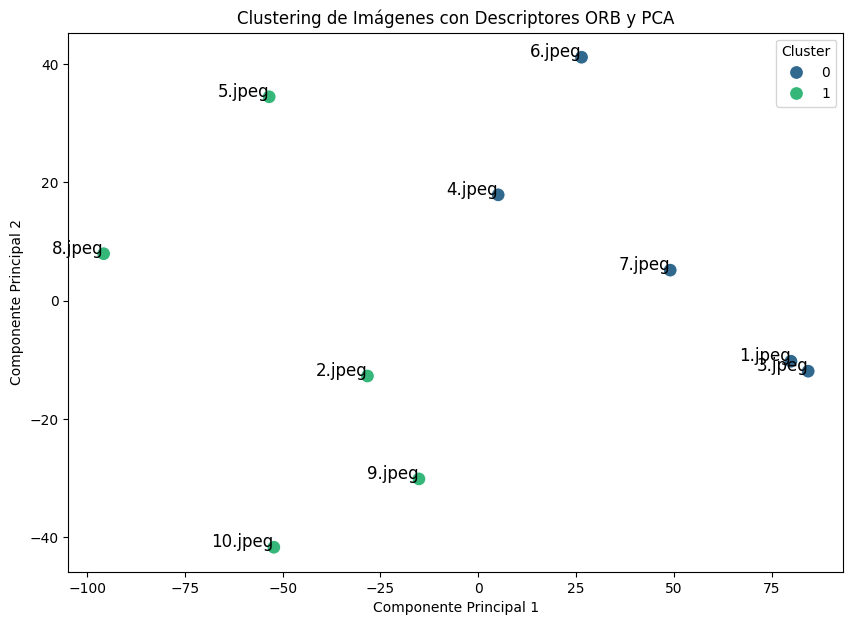

In [125]:
# =====================================================
# 🔹 SECCIÓN 2: Clustering con KMeans 🔹
# =====================================================
"""
# 📌 **Agrupación de imágenes con KMeans**
Aplicamos **KMeans (K=2)** para organizar imágenes con características similares en **dos clusters**.
"""

# --- 📌 Convertir lista de descriptores en matriz ---
vectores_descriptores = np.array(vectores_descriptores)

# --- 📌 Aplicar KMeans ---
num_clusters = 2  # Número de clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(vectores_descriptores)

# =====================================================
# 🔹 SECCIÓN 3: Reducción de Dimensiones con PCA 🔹
# =====================================================
"""
# 📌 **Reducción de Dimensiones con PCA**
Reducimos la dimensionalidad de los descriptores de **32D a 2D** para visualizarlos.
"""

# --- 📌 Aplicar PCA ---
pca = PCA(n_components=2)
vectores_2d = pca.fit_transform(vectores_descriptores)

# =====================================================
# 🔹 SECCIÓN 4: Visualización de Clusters 🔹
# =====================================================
"""
# 📌 **Visualización de Clusters en 2D**
Mostramos un gráfico donde:
- **Cada punto representa una imagen**.
- **Los colores indican los clusters generados por KMeans**.
"""

# --- 📌 Crear gráfico ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x=vectores_2d[:, 0], y=vectores_2d[:, 1], hue=labels, palette="viridis", s=100)

# --- 📌 Agregar etiquetas con los nombres de las imágenes ---
for i, txt in enumerate(nombres_imagenes):
    plt.text(vectores_2d[i, 0], vectores_2d[i, 1], nombres_imagenes[i], fontsize=12, ha='right')

plt.title("Clustering de Imágenes con Descriptores ORB y PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()

---

## 🔹 **4. Cómo se Usa Esto para Agrupar Imágenes (Clustering con KMeans y PCA)**  
📌 **La agrupación de imágenes se basa en encontrar similitudes entre ellas**. Podemos usar histogramas o descriptores para representar las imágenes y luego agruparlas automáticamente usando técnicas como **KMeans y PCA**.

### ✅ **Pasos para Agrupar Imágenes**
1. **Extraer histogramas de escala de grises o color** → Se usa para comparar imágenes por su distribución de color.  
2. **Extraer descriptores ORB** → Se usa para comparar imágenes según su estructura y puntos clave.  
3. **Convertir cada imagen en un vector numérico** (histograma o descriptores).  
4. **Aplicar KMeans para agrupar imágenes en clusters similares**.  
5. **Reducir la dimensionalidad con PCA a 2D para visualizar los grupos**.  

### 🔥 **Ejemplo Práctico**
- Si agrupamos imágenes de **cielos despejados y atardeceres**, el histograma de color identificará diferencias y agrupará imágenes similares.  
- Si agrupamos imágenes de **perros y gatos**, ORB puede detectar diferencias estructurales en sus caras y cuerpos.  

---

## 🎯 **Conclusión**
- **El histograma de escala de grises y color es útil cuando queremos analizar la distribución de colores o intensidades de una imagen.**  
- **Los descriptores de características (ORB, SIFT) nos permiten analizar la estructura y detalles de una imagen.**  
- **Ambos métodos permiten representar imágenes en vectores que pueden agruparse automáticamente mediante clustering.**  